# Technical Skills Session: running an AI model on a GPU

**About 15-20 minutes.**

By the end you'll be able to check whether your environment has a working GPU,
load a real dataset and model from Hugging Face, run a prediction, and see the
GPU actually doing the work.

No PyTorch experience needed. You do need the runtime set to GPU:
**Runtime > Change runtime type > Hardware accelerator > GPU**.

## Part 0 - Setup

Run the cell below, then **restart the runtime** (Runtime > Restart session)
and run it again before continuing.

The restart is not optional. Pip changes what's installed on disk, but a
running kernel keeps the modules it already imported in memory. Without a
restart you get import errors that look like broken packages and aren't.

**Step 1.** Connect your Google Drive. You'll get a permissions prompt.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 2.** Move into the project folder. Colab starts in `/content`, and
every path below is relative to the repository, so this is required.

In [2]:
%cd /content/drive/MyDrive/mmu-gpu-ai-lab

/content/drive/MyDrive/mmu-gpu-ai-lab


**Step 3.** Check you're in the right place. You should see `src`, `api`,
`docs` and `notebook` listed.

In [3]:
!ls

api   environment.yml  notebook    README.md	    src    uvicorn.log
docs  models	       pytest.ini  sample_leaf.jpg  tests


**Step 4.** Install the libraries. Note the version caps - transformers 5.x
renamed the model internals and won't load this checkpoint correctly.

In [4]:
!pip install -q "transformers<5" "datasets==4.0.0" "huggingface-hub<1.0"

**Step 5.** Now restart the runtime: **Runtime > Restart session**, then
re-run steps 1 and 2 above before continuing to Part 1.

Skipping the restart is the single most common cause of confusing import
errors after installing anything in a notebook.

## Part 1 - What's in the environment

Three separate things have to line up before a model can use a GPU:

- **The GPU** - the physical card.
- **The NVIDIA driver** - the software letting the operating system talk to the
  card. Installed at system level, not by pip.
- **CUDA** - NVIDIA's toolkit for running general-purpose code on the GPU.
  PyTorch is compiled against a particular CUDA version and ships that runtime
  with itself, so you don't normally install CUDA separately.

A fourth piece sits on top: **cuDNN**, a library of GPU implementations of the
operations neural networks use most - convolutions, attention, normalisation.
PyTorch calls into it without you asking.

Start by seeing what's actually here.

In [5]:
!nvidia-smi

Sun Aug 30 15:41:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

`nvidia-smi` comes from the driver. If the command isn't found, there's no
NVIDIA driver - which usually means no NVIDIA GPU, or on Colab that the runtime
type is still CPU.

Worth reading in that output:

- **Driver Version** - top left.
- **CUDA Version** - top right. This is the *highest* CUDA this driver can
  support, not a version you installed. It's a ceiling.
- **Name** - which GPU you were given.
- **Memory-Usage** - VRAM used out of total. This decides how large a model or
  batch you can fit.
- **GPU-Util** - how busy the GPU is at this instant. Near 0% when idle.
- **Processes** - what's holding VRAM. Often a crashed notebook kernel.

**Question:** you haven't run any model yet. What do you expect Memory-Usage
and GPU-Util to be?

## Part 2 - Can PyTorch see the GPU?

A driver being present doesn't mean PyTorch can use it.

In [6]:
import torch

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


Now the check that matters:

In [7]:
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
Number of GPUs: 1
GPU name: Tesla T4


`torch.cuda.is_available()` is the check that matters. It returns False when
there's no GPU, no driver, or a PyTorch build without CUDA support - so it tells
you *that* something is wrong, not *what*. Narrowing it down is Part 8.

## Part 3 - CUDA and cuDNN versions

In [8]:
print("PyTorch was built against CUDA:", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())
print("cuDNN enabled:", torch.backends.cudnn.enabled)

PyTorch was built against CUDA: 12.8
cuDNN version: 91900
cuDNN enabled: True


Compare `torch.version.cuda` with the CUDA Version from `nvidia-smi`. They're
usually different numbers, and that's fine: the driver's is a ceiling, PyTorch's
is what it was compiled for. Trouble starts when PyTorch's is *higher*.

cuDNN prints as a packed integer, not a normal version string. Read it as
major/minor/patch: 91900 means 9.19.0, and 90100 would mean 9.1.0.

The project gathers all of this in one place:

In [9]:
!python -m src.gpu_check

Environment
  PyTorch            2.11.0+cu128
  Built against CUDA 12.8
  cuDNN              91900 (enabled=True)
  NVIDIA driver      580.82.07

CUDA available: True
Selected device: cuda:0

Device 0: Tesla T4
  Compute capability  7.5
  Total VRAM          14913 MiB
  Free VRAM           14808 MiB
  Allocated by torch  0 MiB
  Reserved by torch   0 MiB


## Part 4 - Loading a dataset from Hugging Face

The Hugging Face Hub hosts datasets and models. `load_dataset` downloads and
caches one by name, so there's no ZIP file to find and unpack by hand.

We're using photographs of bean leaves in three classes: two diseases and
healthy.

One difference from the project code: this cell asks for the dataset without
specifying a revision, so it gets whatever is currently on the repository's main
branch. `src/dataset.py` pins a specific commit instead. Kept simple here, but
the pinned version is what you'd want for anything whose results you need to
reproduce later - see `docs/REPRODUCIBILITY.md`.

In [10]:
from datasets import load_dataset

beans = load_dataset("AI-Lab-Makerere/beans")
beans

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/18.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})

Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']
Label: angular_leaf_spot


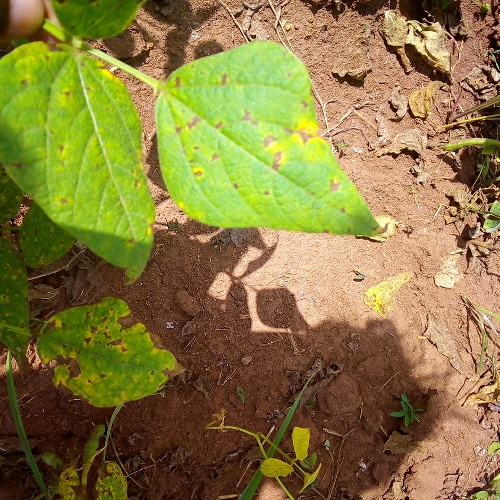

In [11]:
labels = beans["train"].features["labels"]
print("Classes:", labels.names)

example = beans["train"][0]
print("Label:", labels.int2str(example["labels"]))
example["image"]

Notice the dataset arrived already split into train, validation and test. That
split comes from whoever published it, which is one less thing to get wrong.

**Question:** why does it matter that the test split is fixed by the dataset
author rather than chosen by you, when comparing your results with someone
else's?

## Part 5 - Loading the model

Two objects come together here:

- the **processor**, which resizes and normalises an image exactly the way this
  model was trained to expect;
- the **model** itself.

Using the processor that ships with the model matters. Resize to the wrong
dimensions or normalise with the wrong statistics and predictions get quietly
worse, with no error.

In [12]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

MODEL_DIR = "models/vit-beans"

processor = AutoImageProcessor.from_pretrained(MODEL_DIR)
model = AutoModelForImageClassification.from_pretrained(MODEL_DIR)

print("Classes the model knows:", model.config.id2label)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Classes the model knows: {0: 'angular_leaf_spot', 1: 'bean_rust', 2: 'healthy'}


You'll probably see a warning about a "slow image processor". That's expected -
the model was saved with the slower PIL-based processor and it loads the
matching one, which is what you want. Using a different processor at inference
than at training is a real source of quiet accuracy loss.

## Part 6 - Running a prediction

The model and the data have to be on the same device. Sending one to the GPU and
leaving the other on the CPU is probably the most common PyTorch error you'll
hit.

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()
print("Running on:", device)

Running on: cuda


First, preprocess the image. The processor resizes it and normalises the
pixel values, then returns a PyTorch tensor.

Tensor shape: torch.Size([1, 3, 224, 224])


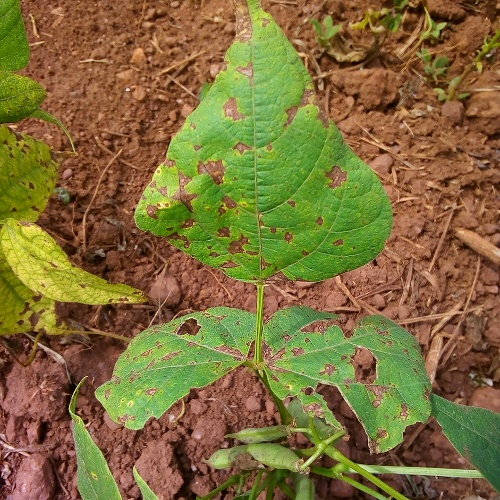

In [14]:
image = beans["test"][0]["image"]

inputs = processor(images=image.convert("RGB"), return_tensors="pt")
print("Tensor shape:", inputs["pixel_values"].shape)
image

The shape reads as (batch, channels, height, width) - one image, 3 colour
channels, 224x224 pixels. The original photo was 500x500; the processor
resized it to what this model expects.

Now move the tensor to the same device as the model and run it.

In [16]:
inputs = {key: value.to(device) for key, value in inputs.items()}

with torch.no_grad():
    logits = model(**inputs).logits

print("Raw logits:", logits)

Raw logits: tensor([[ 2.1355, -0.0828, -2.2011]], device='cuda:0')


Those are raw scores, not probabilities - they don't sum to 1 and can be
negative. Softmax converts them.

In [17]:
probabilities = logits.softmax(dim=-1)[0]
predicted = int(probabilities.argmax())

print("Prediction: ", model.config.id2label[predicted])
print("Confidence: ", round(float(probabilities[predicted]), 3))
print("Actual label:", labels.int2str(beans["test"][0]["labels"]))

Prediction:  angular_leaf_spot
Confidence:  0.891
Actual label: angular_leaf_spot


`torch.no_grad()` tells PyTorch not to track gradients. We're not training, so
the information needed to compute them is wasted memory.

**Question:** the model outputs raw scores called logits. Why apply softmax
before calling anything a confidence?

## Part 7 - Watching the GPU work

Now that a model is loaded, look at memory again.

In [18]:
if torch.cuda.is_available():
    print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.0f} MiB")
    print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**2:.0f} MiB")
    free, total = torch.cuda.mem_get_info()
    print(f"Free:      {free / 1024**2:.0f} MiB of {total / 1024**2:.0f} MiB")
else:
    print("No GPU - nothing to report")

Allocated: 338 MiB
Reserved:  390 MiB
Free:      14390 MiB of 14913 MiB


**Allocated** is memory holding tensors you asked for. **Reserved** is what
PyTorch's allocator has claimed from the GPU and holds onto for reuse. Reserved
is larger, and it's closer to what `nvidia-smi` shows - which is why
`nvidia-smi` often reports more memory in use than you think you're using.

Worth knowing the scale: serving this model uses a few hundred MiB, but training
it peaked above 2 GB. Training stores activations for every layer so it can
compute gradients; inference doesn't.

In [19]:
!nvidia-smi --query-gpu=memory.used,memory.total,utilization.gpu --format=csv

memory.used [MiB], memory.total [MiB], utilization.gpu [%]
523 MiB, 15360 MiB, 0 %


Utilisation will probably read 0% even though the model just ran. `nvidia-smi`
samples one instant, and a single 224x224 image takes a few milliseconds - the
GPU is idle almost all the time between predictions. Memory-Usage is the number
that actually shows something is resident.

## Part 8 - Troubleshooting exercise

Suppose a classmate says "my notebook says CUDA is not available". Work down the
layers, because each step rules one out:

1. **Is there a GPU at all?** Run `nvidia-smi`. Command not found means no
   driver; on Colab it usually means the runtime type is still CPU.
2. **Does PyTorch have CUDA support?** Check `torch.version.cuda`. `None` means a
   CPU-only build got installed - common after someone runs `pip install torch`
   inside Colab and overwrites the working one.
3. **Is the driver new enough?** Compare the CUDA Version in `nvidia-smi` with
   `torch.version.cuda`. PyTorch needing newer CUDA than the driver supports
   will fail.
4. **Did they restart the kernel after installing?** Pip changes disk; a running
   kernel keeps the old modules. This one catches people constantly.
5. **Is something else using the GPU?** Check the Processes table.

Now simulate the fallback - this is what the project's code does when there's no
GPU available:

In [20]:
cpu_model = model.to("cpu")
cpu_inputs = {key: value.to("cpu") for key, value in inputs.items()}

with torch.no_grad():
    cpu_prediction = cpu_model(**cpu_inputs).logits.argmax(dim=-1)

print("CPU prediction:", model.config.id2label[int(cpu_prediction)])
print("Same answer, just slower.")

CPU prediction: angular_leaf_spot
Same answer, just slower.


Note that `.to("cpu")` moved the model in place - `model` is now on the CPU too,
not just `cpu_model`. If you want to go back to the GPU, re-run the Part 6 cell
that calls `.to(device)`.

**Question:** suppose you'd moved the model to CPU but left the inputs on the
GPU. What error would you get, and what's the one-line fix?

---

## Recap

- `nvidia-smi` reports the driver and the card; `torch.cuda.is_available()`
  reports whether your Python environment can use it.
- Driver, CUDA and cuDNN are three different things with three different version
  numbers, and the driver's number is a ceiling.
- Hugging Face gives you the dataset and model by name, with the processor that
  matches the model.
- Model and data must be on the same device.
- Training uses far more VRAM than inference.
- Code that falls back to CPU still works - it's just slower.